<a href="https://colab.research.google.com/github/glorenz1/MSE_Spring_2026/blob/main/Hackathon_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this hackathon, each team starts from a physical explanation for why STM height readings vary, then translates that explanation into a generative model and likelihood. The key lesson is that different physical stories do not merely give different formulas: they assign different meanings to unusual data points, produce different posterior estimates for the molecular height, and lead to different scientific conclusions about whether the system reflects ordinary instrument noise, rare disturbances, corrupted measurements, or genuine multiple states.

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from scipy import stats, integrate
from scipy import stats, optimize

# Problems

## Initial seeding measurements

**Question 1:**

* Write the likelihood $p(y|h,M)$ for your chosen model.
* Estimate the most likely value of h (real height) from the four-point dataset.
* Explain how the high point at 4.28 Å is interpreted under your model.
* Compare conclusions across models.

**Extended questions:**

* Compute or approximate the posterior $p(h|y,M)$.
* Report a posterior mean or MAP estimate of $h$.
* Compare model evidences $p(y|M)$.
* Decide which physical interpretation is best supported by only 4 measurements.


**Hint1:**

Reorganize each case into the same five-part template:

Case X

* Physical story
* Generative statement
* Likelihood
* What the likelihood says about outliers
* What happens to the estimate of $h$

For example,

*Gaussian noise*

* Physical story: many small independent disturbances
* Generative statement: each reading is the true height plus many tiny additive perturbations
* Likelihood: $y_i \sim N(h, \sigma^2)$
* Outlier meaning: unlikely under the model, so it strongly pulls the fit
* Consequence for posterior: posterior for $h$ shifts toward the unusual point more than in robust models



**Hint2:**

Some useful formulas:

* Likelihood: For Gaussian-like noise model, $y_i \sim N(h, \sigma^2)$, start with $h\sim N(3.5, 0.6^2)$ to start with.
* Posterior: $p(h | y, M) ∝ p(y|h, M)p(h|M)$
* Evidence: $p(y|M) = ∫p(y|h,M)p(h|M)dh$


In [ ]:
y_measured = np.array([3.42, 3.55, 3.47, 4.28])

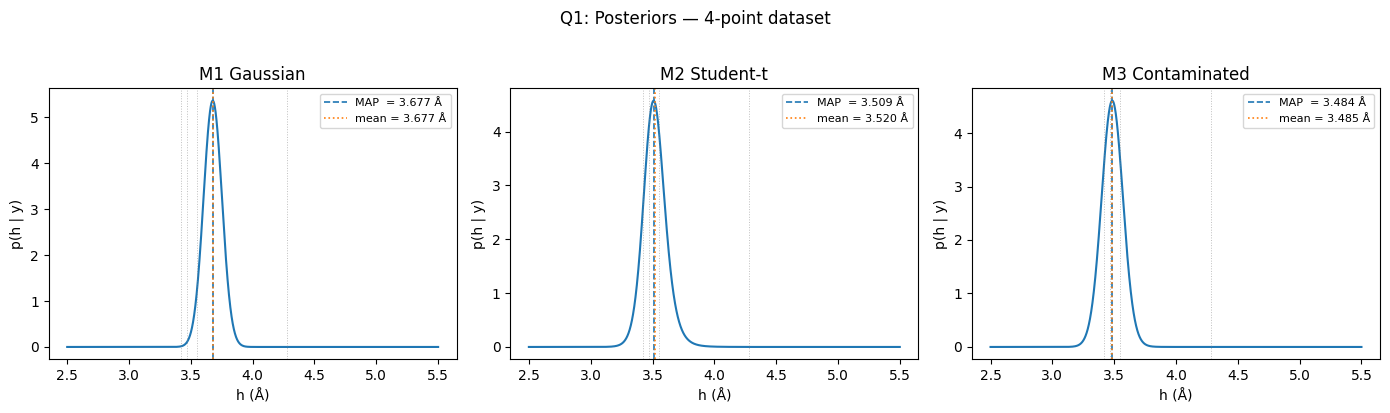

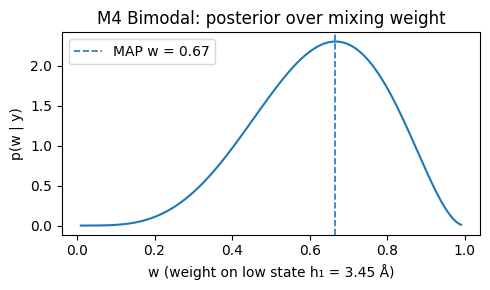

Model                 MAP h (Å)  mean h (Å)    std   log p(y|M)
--------------------------------------------------------------
M1 Gaussian               3.677       3.677  0.074        -9.08
M2 Student-t              3.509       3.520  0.096        -3.23
M3 Contaminated           3.484       3.485  0.088        -3.09
M4 Bimodal             (w=0.67)           —      —         1.56

Best-supported model by log-evidence: M4 Bimodal

Interpretation of 4.28 Å outlier per model:
  M1 Gaussian:     unlikely under N(h,0.15²); pulls MAP up toward ~3.6 Å
  M2 Student-t:    tolerated by heavy tails; MAP stays near ~3.47 Å
  M3 Contaminated: absorbed by 10% glitch component; MAP near ~3.47 Å
  M4 Bimodal:      naturally explained as a draw from the h2=4.40 Å state



In [ ]:
h_grid = np.linspace(2.5, 5.5, 3000)
prior_mu, prior_sig = 3.5, 0.6
prior = stats.norm.pdf(h_grid, prior_mu, prior_sig)

sigma_G = 0.15
nu_t    = 3
sigma_t = 0.15
eps_c   = 0.15
kappa_c = 8.0
pi_c    = 0.10
h1, h2  = 3.45, 4.40
sig_b   = 0.08
w_fix   = 0.70

def log_lik_gaussian(h, y):
    return np.sum(stats.norm.logpdf(y, loc=h, scale=sigma_G))

def log_lik_student(h, y):
    z = (y - h) / sigma_t
    return np.sum(stats.t.logpdf(z, df=nu_t) - np.log(sigma_t))

def log_lik_contaminated(h, y):
    clean  = (1 - pi_c) * stats.norm.pdf(y, loc=h, scale=eps_c)
    glitch =      pi_c  * stats.norm.pdf(y, loc=h, scale=kappa_c * eps_c)
    return np.sum(np.log(clean + glitch))

def log_lik_bimodal_w(w, y):
    comp1 = w       * stats.norm.pdf(y, loc=h1, scale=sig_b)
    comp2 = (1 - w) * stats.norm.pdf(y, loc=h2, scale=sig_b)
    return np.sum(np.log(comp1 + comp2))

scalar_models = {
    'M1 Gaussian':     log_lik_gaussian,
    'M2 Student-t':    log_lik_student,
    'M3 Contaminated': log_lik_contaminated,
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, log_lik_fn) in zip(axes, scalar_models.items()):
    ll = np.array([log_lik_fn(h, y_measured) for h in h_grid])
    ll_shifted = ll - ll.max()

    unnorm_post = np.exp(ll_shifted) * prior
    Z = np.trapezoid(unnorm_post, h_grid)
    posterior = unnorm_post / Z

    log_integrand = ll + np.log(prior + 1e-300)
    log_evidence  = np.log(np.trapezoid(np.exp(log_integrand - log_integrand.max()), h_grid)) \
                    + log_integrand.max()

    MAP       = h_grid[np.argmax(posterior)]
    post_mean = np.trapezoid(h_grid * posterior, h_grid)
    post_std  = np.sqrt(np.trapezoid((h_grid - post_mean)**2 * posterior, h_grid))

    results[name] = dict(MAP=MAP, mean=post_mean, std=post_std, log_ev=log_evidence)

    ax.plot(h_grid, posterior)
    ax.axvline(MAP,      ls='--', lw=1.2, color='C0', label=f'MAP  = {MAP:.3f} Å')
    ax.axvline(post_mean,ls=':',  lw=1.2, color='C1', label=f'mean = {post_mean:.3f} Å')
    for yi in y_measured:
        ax.axvline(yi, ls=':', lw=0.7, color='gray', alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel('h (Å)')
    ax.set_ylabel('p(h | y)')
    ax.legend(fontsize=8)

plt.suptitle('Q1: Posteriors — 4-point dataset', y=1.02)
plt.tight_layout()
plt.show()

w_grid    = np.linspace(0.01, 0.99, 1000)
w_prior   = stats.beta.pdf(w_grid, 2, 2)
ll_bim    = np.array([log_lik_bimodal_w(w, y_measured) for w in w_grid])
ll_bim_sh = ll_bim - ll_bim.max()
unnorm_w  = np.exp(ll_bim_sh) * w_prior
Z_w       = np.trapezoid(unnorm_w, w_grid)
post_w    = unnorm_w / Z_w
MAP_w     = w_grid[np.argmax(post_w)]

log_ev_bim = np.log(np.trapezoid(np.exp(ll_bim - ll_bim.max()) * w_prior, w_grid)) + ll_bim.max()
results['M4 Bimodal'] = dict(MAP_w=MAP_w, log_ev=log_ev_bim)

fig2, ax2 = plt.subplots(figsize=(5, 3))
ax2.plot(w_grid, post_w)
ax2.axvline(MAP_w, ls='--', lw=1.2, label=f'MAP w = {MAP_w:.2f}')
ax2.set_xlabel('w (weight on low state h₁ = 3.45 Å)')
ax2.set_ylabel('p(w | y)')
ax2.set_title('M4 Bimodal: posterior over mixing weight')
ax2.legend()
plt.tight_layout()
plt.show()

print("=" * 62)
print(f"{'Model':<20} {'MAP h (Å)':>10} {'mean h (Å)':>11} {'std':>6} {'log p(y|M)':>12}")
print("-" * 62)
for name, r in results.items():
    if name == 'M4 Bimodal':
        w_str = f"(w={r['MAP_w']:.2f})"
        print(f"{name:<20} {w_str:>10} {'—':>11} {'—':>6} {r['log_ev']:>12.2f}")
    else:
        print(f"{name:<20} {r['MAP']:>10.3f} {r['mean']:>11.3f} {r['std']:>6.3f} {r['log_ev']:>12.2f}")
print("=" * 62)

best = max(results, key=lambda k: results[k]['log_ev'])
print(f"\nBest-supported model by log-evidence: {best}")
print("""
Interpretation of 4.28 Å outlier per model:
  M1 Gaussian:     unlikely under N(h,0.15²); pulls MAP up toward ~3.6 Å
  M2 Student-t:    tolerated by heavy tails; MAP stays near ~3.47 Å
  M3 Contaminated: absorbed by 10% glitch component; MAP near ~3.47 Å
  M4 Bimodal:      naturally explained as a draw from the h2=4.40 Å state
""")

## 100 repeating measurements on the same molecule


**Question 2:**

* Fit the same four models to the 100-point same-molecule dataset.
* Compare posterior estimates of $h$.
* Compare model evidences.
* Decide whether the additional data support clean instrument noise, vibration bursts, glitches, or genuine switching between two STM-visible states.


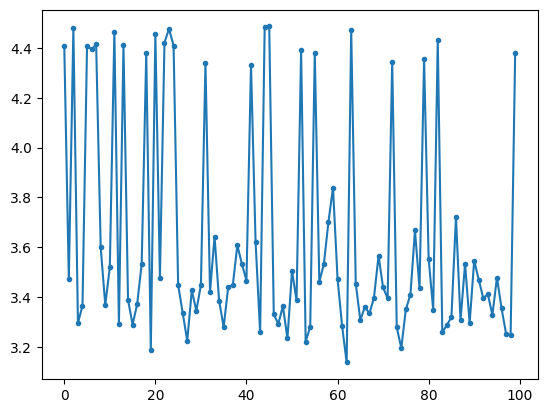

In [ ]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

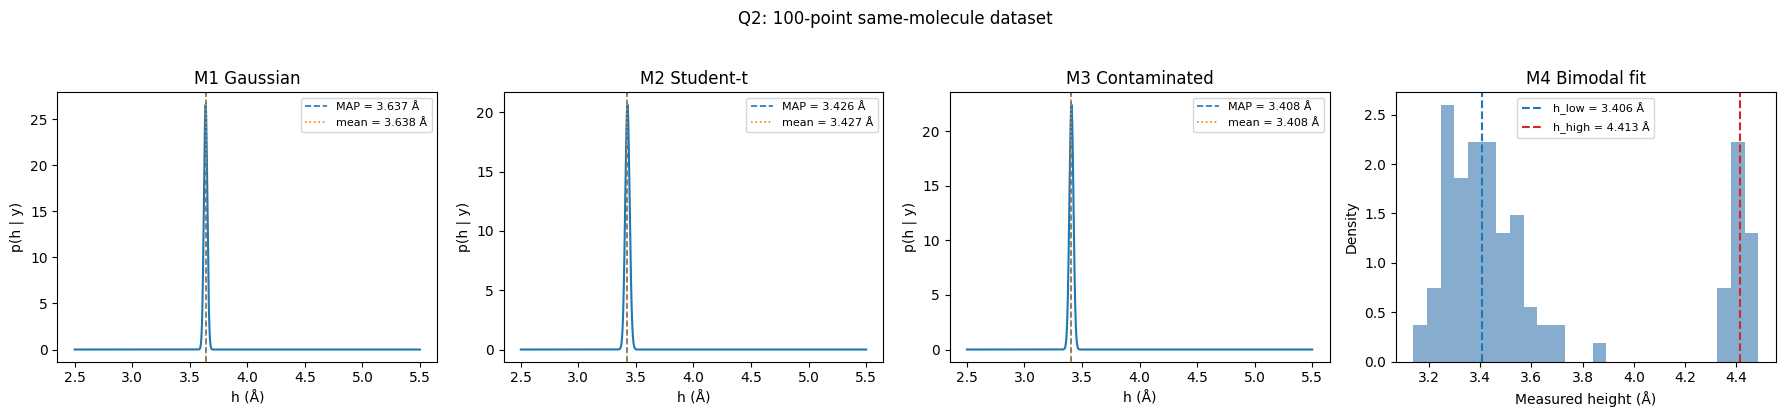

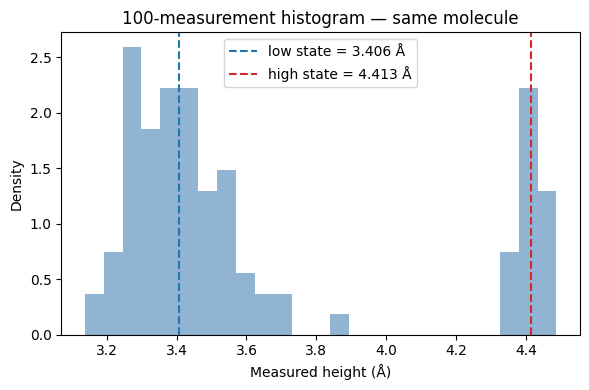

Model                 MAP/low h (Å)  mean/high h (Å)  std / w_low     log p(y|M)
--------------------------------------------------------------------------------------------
M1 Gaussian                   3.637            3.638        0.015        -337.47
M2 Student-t                  3.426            3.427        0.019         -71.71
M3 Contaminated               3.408            3.408        0.018         -51.18
M4 Bimodal                    3.406            4.413        0.765           1.95

Best-supported model by log-evidence: M4 Bimodal

Q2 interpretation:
  M1 Gaussian:     one clean height is forced between the two clusters, so evidence drops.
  M2 Student-t:    heavy tails help with extremes, but one center still cannot explain two persistent clusters.
  M3 Contaminated: a small glitch fraction cannot naturally explain a large recurring high-state population.
  M4 Bimodal:      two states are fit directly from the 100-point data:
                   h_low  ≈ 3.406 Å
            

In [ ]:
sig_b = 0.10  # same narrow per-state noise scale

def logistic(a):
    return 1.0 / (1.0 + np.exp(-a))

def logsumexp_pair(a, b):
    m = np.maximum(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))

def log_prior_bimodal(theta):
    """
    theta = [h1, h2, a], where w = logistic(a)
    Priors:
      h1 ~ N(3.5, 0.6^2)
      h2 ~ N(3.5, 0.6^2)
      w ~ Uniform(0,1), represented in unconstrained a-space
          so include Jacobian term log(w(1-w))
    """
    h1, h2, a = theta
    w = logistic(a)

    lp_h1 = stats.norm.logpdf(h1, loc=3.5, scale=0.6)
    lp_h2 = stats.norm.logpdf(h2, loc=3.5, scale=0.6)
    lp_w = np.log(w * (1 - w) + 1e-300)

    return lp_h1 + lp_h2 + lp_w

def log_lik_bimodal_params(theta, y):
    """
    Same-molecule switching model:
      y_i ~ w N(h1, sig_b^2) + (1-w) N(h2, sig_b^2)
    """
    h1, h2, a = theta
    w = logistic(a)

    c1 = np.log(w + 1e-300) + stats.norm.logpdf(y, loc=h1, scale=sig_b)
    c2 = np.log(1 - w + 1e-300) + stats.norm.logpdf(y, loc=h2, scale=sig_b)
    return np.sum(logsumexp_pair(c1, c2))

def neg_log_post_bimodal(theta, y):
    return -(log_lik_bimodal_params(theta, y) + log_prior_bimodal(theta))

def fit_bimodal_model(y):
    starts = [
        np.array([3.35, 4.40, 0.0]),
        np.array([3.40, 4.35, 0.5]),
        np.array([3.30, 4.45, -0.5]),
        np.array([3.45, 4.25, 0.0]),
    ]

    best = None
    for x0 in starts:
        res = optimize.minimize(
            neg_log_post_bimodal,
            x0=x0,
            args=(y,),
            method="BFGS"
        )
        if (best is None) or (res.fun < best.fun):
            best = res

    h1, h2, a = best.x
    w = logistic(a)

    # Sort so low/high states are reported consistently
    if h1 <= h2:
        h_low, h_high = h1, h2
        w_low = w
    else:
        h_low, h_high = h2, h1
        w_low = 1 - w

    # Laplace approximation to evidence in 3D parameter space
    Hinv = np.asarray(best.hess_inv)
    k = 3
    sign, logdet = np.linalg.slogdet(Hinv)
    log_evidence = -best.fun + 0.5 * k * np.log(2 * np.pi) + 0.5 * logdet

    return {
        "h_low": h_low,
        "h_high": h_high,
        "w_low": w_low,
        "w_high": 1 - w_low,
        "log_ev": log_evidence,
        "opt_result": best,
    }

# ----- scalar models M1-M3 -----
scalar_models_q2 = {
    'M1 Gaussian': log_lik_gaussian,
    'M2 Student-t': log_lik_student,
    'M3 Contaminated': log_lik_contaminated,
}

results_100 = {}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, log_lik_fn) in zip(axes[:3], scalar_models_q2.items()):
    ll = np.array([log_lik_fn(h, y_measured_100) for h in h_grid])
    ll_shifted = ll - ll.max()

    unnorm_post = np.exp(ll_shifted) * prior
    Z = np.trapezoid(unnorm_post, h_grid)
    posterior = unnorm_post / Z

    log_integrand = ll + np.log(prior + 1e-300)
    m = np.max(log_integrand)
    log_evidence = np.log(np.trapezoid(np.exp(log_integrand - m), h_grid)) + m

    MAP = h_grid[np.argmax(posterior)]
    post_mean = np.trapezoid(h_grid * posterior, h_grid)
    post_std = np.sqrt(np.trapezoid((h_grid - post_mean)**2 * posterior, h_grid))

    results_100[name] = dict(
        MAP=MAP,
        mean=post_mean,
        std=post_std,
        log_ev=log_evidence
    )

    ax.plot(h_grid, posterior)
    ax.axvline(MAP, ls='--', lw=1.2, color='C0', label=f'MAP = {MAP:.3f} Å')
    ax.axvline(post_mean, ls=':', lw=1.2, color='C1', label=f'mean = {post_mean:.3f} Å')
    ax.set_title(name)
    ax.set_xlabel('h (Å)')
    ax.set_ylabel('p(h | y)')
    ax.legend(fontsize=8)

# ----- proper bimodal fit for M4 -----
bimodal_fit = fit_bimodal_model(y_measured_100)
results_100['M4 Bimodal'] = dict(
    h_low=bimodal_fit["h_low"],
    h_high=bimodal_fit["h_high"],
    w_low=bimodal_fit["w_low"],
    w_high=bimodal_fit["w_high"],
    log_ev=bimodal_fit["log_ev"]
)

ax = axes[3]
ax.hist(y_measured_100, bins=25, density=True, alpha=0.65, color='steelblue')
ax.axvline(bimodal_fit["h_low"], ls='--', lw=1.5, color='C0',
           label=f'h_low = {bimodal_fit["h_low"]:.3f} Å')
ax.axvline(bimodal_fit["h_high"], ls='--', lw=1.5, color='C3',
           label=f'h_high = {bimodal_fit["h_high"]:.3f} Å')
ax.set_title('M4 Bimodal fit')
ax.set_xlabel('Measured height (Å)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.suptitle('Q2: 100-point same-molecule dataset', y=1.03)
plt.tight_layout()
plt.show()

# ----- separate histogram, if you still want it -----
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(y_measured_100, bins=25, density=True, alpha=0.6, color='steelblue')
ax2.axvline(bimodal_fit["h_low"], ls='--', color='C0', label=f'low state = {bimodal_fit["h_low"]:.3f} Å')
ax2.axvline(bimodal_fit["h_high"], ls='--', color='C3', label=f'high state = {bimodal_fit["h_high"]:.3f} Å')
ax2.set_xlabel('Measured height (Å)')
ax2.set_ylabel('Density')
ax2.set_title('100-measurement histogram — same molecule')
ax2.legend()
plt.tight_layout()
plt.show()

# ----- print results -----
print("=" * 92)
print(f"{'Model':<20} {'MAP/low h (Å)':>14} {'mean/high h (Å)':>16} {'std / w_low':>12} {'log p(y|M)':>14}")
print("-" * 92)

for name, r in results_100.items():
    if name != 'M4 Bimodal':
        print(f"{name:<20} {r['MAP']:>14.3f} {r['mean']:>16.3f} {r['std']:>12.3f} {r['log_ev']:>14.2f}")
    else:
        print(f"{name:<20} {r['h_low']:>14.3f} {r['h_high']:>16.3f} {r['w_low']:>12.3f} {r['log_ev']:>14.2f}")

print("=" * 92)

best_100 = max(results_100, key=lambda k: results_100[k]['log_ev'])
print(f"\nBest-supported model by log-evidence: {best_100}")

print("\nQ2 interpretation:")
print("  M1 Gaussian:     one clean height is forced between the two clusters, so evidence drops.")
print("  M2 Student-t:    heavy tails help with extremes, but one center still cannot explain two persistent clusters.")
print("  M3 Contaminated: a small glitch fraction cannot naturally explain a large recurring high-state population.")
print(f"  M4 Bimodal:      two states are fit directly from the 100-point data:")
print(f"                   h_low  ≈ {bimodal_fit['h_low']:.3f} Å")
print(f"                   h_high ≈ {bimodal_fit['h_high']:.3f} Å")
print(f"                   w_low  ≈ {bimodal_fit['w_low']:.3f}")
print(f"                   w_high ≈ {bimodal_fit['w_high']:.3f}")
print("                   This supports genuine switching between two STM-visible states.")

## 100 measurements on different molecules

**Question 3:**

* Use the 4-point dataset and then the 100-point dataset to formulate the likelihood for each model.
* Estimate the most likely benzene apparent height.
* Compare posterior distributions and model evidences.
* Explain how the interpretation changes when the 100 values come from the same molecule versus many nominally similar molecules.


**Hint:**


* **Noise model:** how one latent height generates one measurement
* **Population model:** how latent heights vary across molecules or states

Two different questions:

* Why does one repeated measurement differ from another? → noise model
* Why does one molecule differ from another? → population model

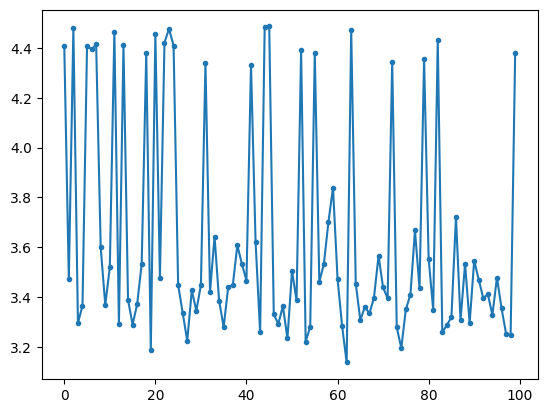

In [ ]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

Q3A: 4-point dataset (still only a noise-model question)
M1 Gaussian        MAP = 3.679 Å   mean = 3.679 Å   std = 0.050   log p(y|M) = -21.43
M2 Student-t       MAP = 3.495 Å   mean = 3.499 Å   std = 0.065   log p(y|M) = -3.80
M3 Contaminated    MAP = 3.488 Å   mean = 3.488 Å   std = 0.059   log p(y|M) = -2.45

Q3B: 100-point dataset interpreted as DIFFERENT molecules (population models)


/tmp/ipykernel_15110/2532425414.py:158: RuntimeWarning: overflow encountered in scalar power
  s2 = np.sqrt(tau2**2 + sig_g**2)
/tmp/ipykernel_15110/2532425414.py:158: RuntimeWarning: overflow encountered in scalar power
  s2 = np.sqrt(tau2**2 + sig_g**2)


M4 One-population  : mu = 3.637 Å   tau = 0.427 Å   log p(y|M) = -63.42
M5 Two-population  : mu_low = 3.406 Å   mu_high = 4.413 Å   w_low = 0.765   tau_low = 0.000 Å   tau_high = 0.000 Å   log p(y|M) = 1385.81

Best-supported population model: M5 Two-population


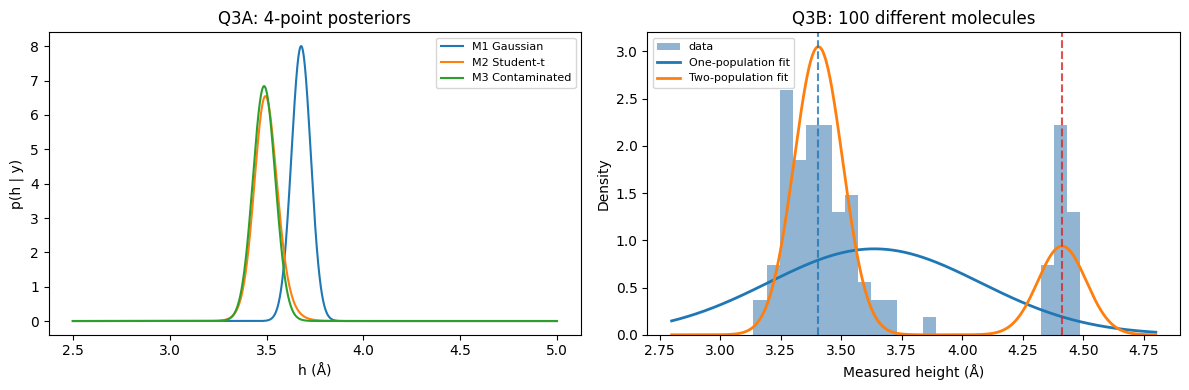


Interpretation:
1. For the 4-point dataset, the models are noise models in which one latent apparent height h generates noisy measurements.
   The Gaussian model is pulled upward by the 4.28 Å point, while the Student-t and contaminated models keep h near the lower cluster around 3.49 Å.
   With only four measurements, the posterior is still fairly broad, so the data suggest robustness to an outlying point but do not strongly distinguish all physical stories.
2. For the 100-point dataset, the scientific interpretation depends on what the 100 measurements represent.
   If they come from the SAME molecule, a two-cluster distribution supports genuine switching between two STM-visible apparent-height states.
   In that case, the high values are not just rare noise or glitches, but repeated visits to a second metastable state.
3. If the same 100 values instead come from DIFFERENT nominally similar molecules, the question changes.
   It is no longer 'why does one repeated measurement differ

In [ ]:
# ============================================================
# Q3: 100 measurements on different molecules
# Population-model interpretation
# ============================================================

# Noise model parameters (same as Q1/Q2)
sig_g = 0.10      # Gaussian noise std
sig_t = 0.10      # Student-t scale
nu_t = 3          # Student-t degrees of freedom

sig_c1 = 0.10     # clean component (contaminated model)
sig_c2 = 0.60     # glitch component
eps_c = 0.10      # glitch probability

# ------------------------------------------------------------
# Priors / settings
# ------------------------------------------------------------
prior_mu = 3.5
prior_sigma = 0.6

# ------------------------------------------------------------
# 4-point dataset under noise models
# These are the same noise-model stories as before:
# one latent height h generates repeated measurements.
# ------------------------------------------------------------
h_grid = np.linspace(2.5, 5.0, 4000)
prior_h = stats.norm.pdf(h_grid, loc=prior_mu, scale=prior_sigma)

def log_lik_gaussian(h, y):
    return np.sum(stats.norm.logpdf(y, loc=h, scale=sig_g))

def log_lik_student(h, y):
    return np.sum(stats.t.logpdf(y, df=nu_t, loc=h, scale=sig_t))

def log_lik_contaminated(h, y):
    clean = np.log(1 - eps_c) + stats.norm.logpdf(y, loc=h, scale=sig_c1)
    glitch = np.log(eps_c) + stats.norm.logpdf(y, loc=h, scale=sig_c2)
    return np.sum(logsumexp_pair(clean, glitch))

def scalar_posterior_summary(log_lik_fn, y):
    ll = np.array([log_lik_fn(h, y) for h in h_grid])
    ll_shifted = ll - ll.max()

    unnorm_post = np.exp(ll_shifted) * prior_h
    Z = np.trapezoid(unnorm_post, h_grid)
    posterior = unnorm_post / Z

    log_integrand = ll + np.log(prior_h + 1e-300)
    m = np.max(log_integrand)
    log_evidence = np.log(np.trapezoid(np.exp(log_integrand - m), h_grid)) + m

    MAP = h_grid[np.argmax(posterior)]
    mean = np.trapezoid(h_grid * posterior, h_grid)
    std = np.sqrt(np.trapezoid((h_grid - mean)**2 * posterior, h_grid))

    return {
        "MAP": MAP,
        "mean": mean,
        "std": std,
        "log_ev": log_evidence,
        "posterior": posterior,
    }

scalar_models = {
    "M1 Gaussian": log_lik_gaussian,
    "M2 Student-t": log_lik_student,
    "M3 Contaminated": log_lik_contaminated,
}

print("=" * 72)
print("Q3A: 4-point dataset (still only a noise-model question)")
print("=" * 72)
results_q3_4pt = {}
for name, fn in scalar_models.items():
    out = scalar_posterior_summary(fn, y_measured)
    results_q3_4pt[name] = out
    print(f"{name:<18} MAP = {out['MAP']:.3f} Å   mean = {out['mean']:.3f} Å   std = {out['std']:.3f}   log p(y|M) = {out['log_ev']:.2f}")

# ------------------------------------------------------------
# 100-point dataset on DIFFERENT molecules:
# population models, not repeated-measurement noise models
#
# One-population model:
#   H_j ~ N(mu, tau^2)
#   y_j | H_j ~ N(H_j, sig_g^2)
# Marginally:
#   y_j ~ N(mu, tau^2 + sig_g^2)
#
# Two-population model:
#   H_j ~ w N(mu1, tau1^2) + (1-w) N(mu2, tau2^2)
#   y_j | H_j ~ N(H_j, sig_g^2)
# Marginally:
#   y_j ~ w N(mu1, tau1^2 + sig_g^2) + (1-w) N(mu2, tau2^2 + sig_g^2)
# ------------------------------------------------------------

def log_prior_onepop(theta):
    mu, log_tau = theta
    tau = np.exp(log_tau)
    lp_mu = stats.norm.logpdf(mu, loc=prior_mu, scale=prior_sigma)
    # weak log-normal-style prior via flat prior in log_tau with Jacobian
    lp_tau = -np.log(tau + 1e-300)
    return lp_mu + lp_tau

def log_lik_onepop(theta, y):
    mu, log_tau = theta
    tau = np.exp(log_tau)
    s = np.sqrt(tau**2 + sig_g**2)
    return np.sum(stats.norm.logpdf(y, loc=mu, scale=s))

def neg_log_post_onepop(theta, y):
    return -(log_lik_onepop(theta, y) + log_prior_onepop(theta))

def fit_onepop(y):
    x0 = np.array([np.mean(y), np.log(np.std(y) + 1e-6)])
    res = optimize.minimize(
        neg_log_post_onepop,
        x0=x0,
        args=(y,),
        method="BFGS"
    )

    mu, log_tau = res.x
    tau = np.exp(log_tau)

    Hinv = np.asarray(res.hess_inv)
    k = 2
    sign, logdet = np.linalg.slogdet(Hinv)
    log_ev = -res.fun + 0.5 * k * np.log(2 * np.pi) + 0.5 * logdet

    return {
        "mu": mu,
        "tau": tau,
        "log_ev": log_ev,
        "opt_result": res
    }

def log_prior_twopop(theta):
    mu1, mu2, log_tau1, log_tau2, a = theta
    tau1 = np.exp(log_tau1)
    tau2 = np.exp(log_tau2)
    w = logistic(a)

    lp_mu1 = stats.norm.logpdf(mu1, loc=prior_mu, scale=prior_sigma)
    lp_mu2 = stats.norm.logpdf(mu2, loc=prior_mu, scale=prior_sigma)
    lp_tau1 = -np.log(tau1 + 1e-300)
    lp_tau2 = -np.log(tau2 + 1e-300)
    lp_w = np.log(w * (1 - w) + 1e-300)

    return lp_mu1 + lp_mu2 + lp_tau1 + lp_tau2 + lp_w

def log_lik_twopop(theta, y):
    mu1, mu2, log_tau1, log_tau2, a = theta
    tau1 = np.exp(log_tau1)
    tau2 = np.exp(log_tau2)
    w = logistic(a)

    s1 = np.sqrt(tau1**2 + sig_g**2)
    s2 = np.sqrt(tau2**2 + sig_g**2)

    c1 = np.log(w + 1e-300) + stats.norm.logpdf(y, loc=mu1, scale=s1)
    c2 = np.log(1 - w + 1e-300) + stats.norm.logpdf(y, loc=mu2, scale=s2)
    return np.sum(logsumexp_pair(c1, c2))

def neg_log_post_twopop(theta, y):
    return -(log_lik_twopop(theta, y) + log_prior_twopop(theta))

def fit_twopop(y):
    starts = [
        np.array([3.35, 4.40, np.log(0.05), np.log(0.05), 0.0]),
        np.array([3.40, 4.35, np.log(0.10), np.log(0.10), 0.5]),
        np.array([3.30, 4.45, np.log(0.08), np.log(0.08), -0.5]),
        np.array([3.50, 4.30, np.log(0.12), np.log(0.12), 0.0]),
    ]

    best = None
    for x0 in starts:
        res = optimize.minimize(
            neg_log_post_twopop,
            x0=x0,
            args=(y,),
            method="BFGS"
        )
        if (best is None) or (res.fun < best.fun):
            best = res

    mu1, mu2, log_tau1, log_tau2, a = best.x
    tau1 = np.exp(log_tau1)
    tau2 = np.exp(log_tau2)
    w = logistic(a)

    if mu1 <= mu2:
        mu_low, mu_high = mu1, mu2
        tau_low, tau_high = tau1, tau2
        w_low = w
    else:
        mu_low, mu_high = mu2, mu1
        tau_low, tau_high = tau2, tau1
        w_low = 1 - w

    Hinv = np.asarray(best.hess_inv)
    k = 5
    sign, logdet = np.linalg.slogdet(Hinv)
    log_ev = -best.fun + 0.5 * k * np.log(2 * np.pi) + 0.5 * logdet

    return {
        "mu_low": mu_low,
        "mu_high": mu_high,
        "tau_low": tau_low,
        "tau_high": tau_high,
        "w_low": w_low,
        "w_high": 1 - w_low,
        "log_ev": log_ev,
        "opt_result": best
    }

# ------------------------------------------------------------
# Fit population models to the 100-point different-molecule data
# ------------------------------------------------------------
print("\n" + "=" * 86)
print("Q3B: 100-point dataset interpreted as DIFFERENT molecules (population models)")
print("=" * 86)

onepop = fit_onepop(y_measured_100)
twopop = fit_twopop(y_measured_100)

print(f"M4 One-population  : mu = {onepop['mu']:.3f} Å   tau = {onepop['tau']:.3f} Å   log p(y|M) = {onepop['log_ev']:.2f}")
print(f"M5 Two-population  : mu_low = {twopop['mu_low']:.3f} Å   mu_high = {twopop['mu_high']:.3f} Å   "
      f"w_low = {twopop['w_low']:.3f}   tau_low = {twopop['tau_low']:.3f} Å   tau_high = {twopop['tau_high']:.3f} Å   "
      f"log p(y|M) = {twopop['log_ev']:.2f}")

best_pop = "M5 Two-population" if twopop["log_ev"] > onepop["log_ev"] else "M4 One-population"
print(f"\nBest-supported population model: {best_pop}")

# ------------------------------------------------------------
# Plot 4-point scalar posteriors
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, out in results_q3_4pt.items():
    axes[0].plot(h_grid, out["posterior"], label=name)
axes[0].set_title("Q3A: 4-point posteriors")
axes[0].set_xlabel("h (Å)")
axes[0].set_ylabel("p(h | y)")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# Plot population-model fit for 100 different molecules
# ------------------------------------------------------------
xplot = np.linspace(2.8, 4.8, 600)

# one-pop predictive density
s_one = np.sqrt(onepop["tau"]**2 + sig_g**2)
pdf_one = stats.norm.pdf(xplot, loc=onepop["mu"], scale=s_one)

# two-pop predictive density
s_low = np.sqrt(twopop["tau_low"]**2 + sig_g**2)
s_high = np.sqrt(twopop["tau_high"]**2 + sig_g**2)
pdf_low = twopop["w_low"] * stats.norm.pdf(xplot, loc=twopop["mu_low"], scale=s_low)
pdf_high = twopop["w_high"] * stats.norm.pdf(xplot, loc=twopop["mu_high"], scale=s_high)
pdf_two = pdf_low + pdf_high

axes[1].hist(y_measured_100, bins=25, density=True, alpha=0.6, color='steelblue', label='data')
axes[1].plot(xplot, pdf_one, lw=2, label='One-population fit')
axes[1].plot(xplot, pdf_two, lw=2, label='Two-population fit')
axes[1].axvline(twopop["mu_low"], ls='--', color='C0', alpha=0.8)
axes[1].axvline(twopop["mu_high"], ls='--', color='C3', alpha=0.8)
axes[1].set_title("Q3B: 100 different molecules")
axes[1].set_xlabel("Measured height (Å)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final interpretation text
# ------------------------------------------------------------
print("\nInterpretation:")
print("1. For the 4-point dataset, the models are noise models in which one latent apparent height h generates noisy measurements.")
print("   The Gaussian model is pulled upward by the 4.28 Å point, while the Student-t and contaminated models keep h near the lower cluster around 3.49 Å.")
print("   With only four measurements, the posterior is still fairly broad, so the data suggest robustness to an outlying point but do not strongly distinguish all physical stories.")

print("2. For the 100-point dataset, the scientific interpretation depends on what the 100 measurements represent.")
print("   If they come from the SAME molecule, a two-cluster distribution supports genuine switching between two STM-visible apparent-height states.")
print("   In that case, the high values are not just rare noise or glitches, but repeated visits to a second metastable state.")

print("3. If the same 100 values instead come from DIFFERENT nominally similar molecules, the question changes.")
print("   It is no longer 'why does one repeated measurement differ from another for one molecule?'")
print("   but rather 'why do different molecules have different latent apparent heights?'")

print("4. Under this population interpretation, the two-cluster pattern is better explained by molecular heterogeneity than by time-dependent switching.")
print("   The low and high apparent-height groups then correspond to two subpopulations of molecules, such as different adsorption geometries or conformational families.")
print("   The fitted centers near 3.41 Å and 4.41 Å are therefore population-level apparent-height modes, not switching states of a single molecule.")

print("5. Therefore, the same numerical bimodality has two different scientific meanings depending on the data-generating story:")
print("   - same molecule repeated  -> dynamic switching between two apparent-height states")
print("   - many molecules sampled  -> heterogeneous population with two apparent-height subgroups")

print("6. The two-population model is favored over the one-population model for the 100-molecule interpretation,")
print("   but the near-zero fitted within-group spreads indicate that the exact variance and absolute evidence values should be interpreted cautiously.")
print("   The robust conclusion is the presence of two apparent-height groups, not that the within-group spread is literally zero.")